In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

In [4]:
 # Step 2: Load Dataset
df = pd.read_csv('Iris.csv')
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
# Step 3: Dataset Info
print("\nTotal Rows:", df.shape[0])
print("Total Columns:", df.shape[1])


Total Rows: 150
Total Columns: 6

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing Values in Each Column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [6]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [7]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


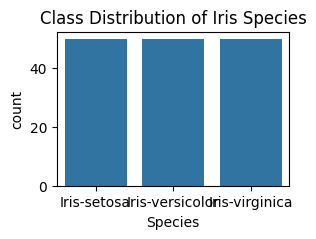

In [8]:
# Class Distribution
plt.figure(figsize=(3,2))
sns.countplot(x='Species', data=df)
plt.title("Class Distribution of Iris Species")
plt.show()

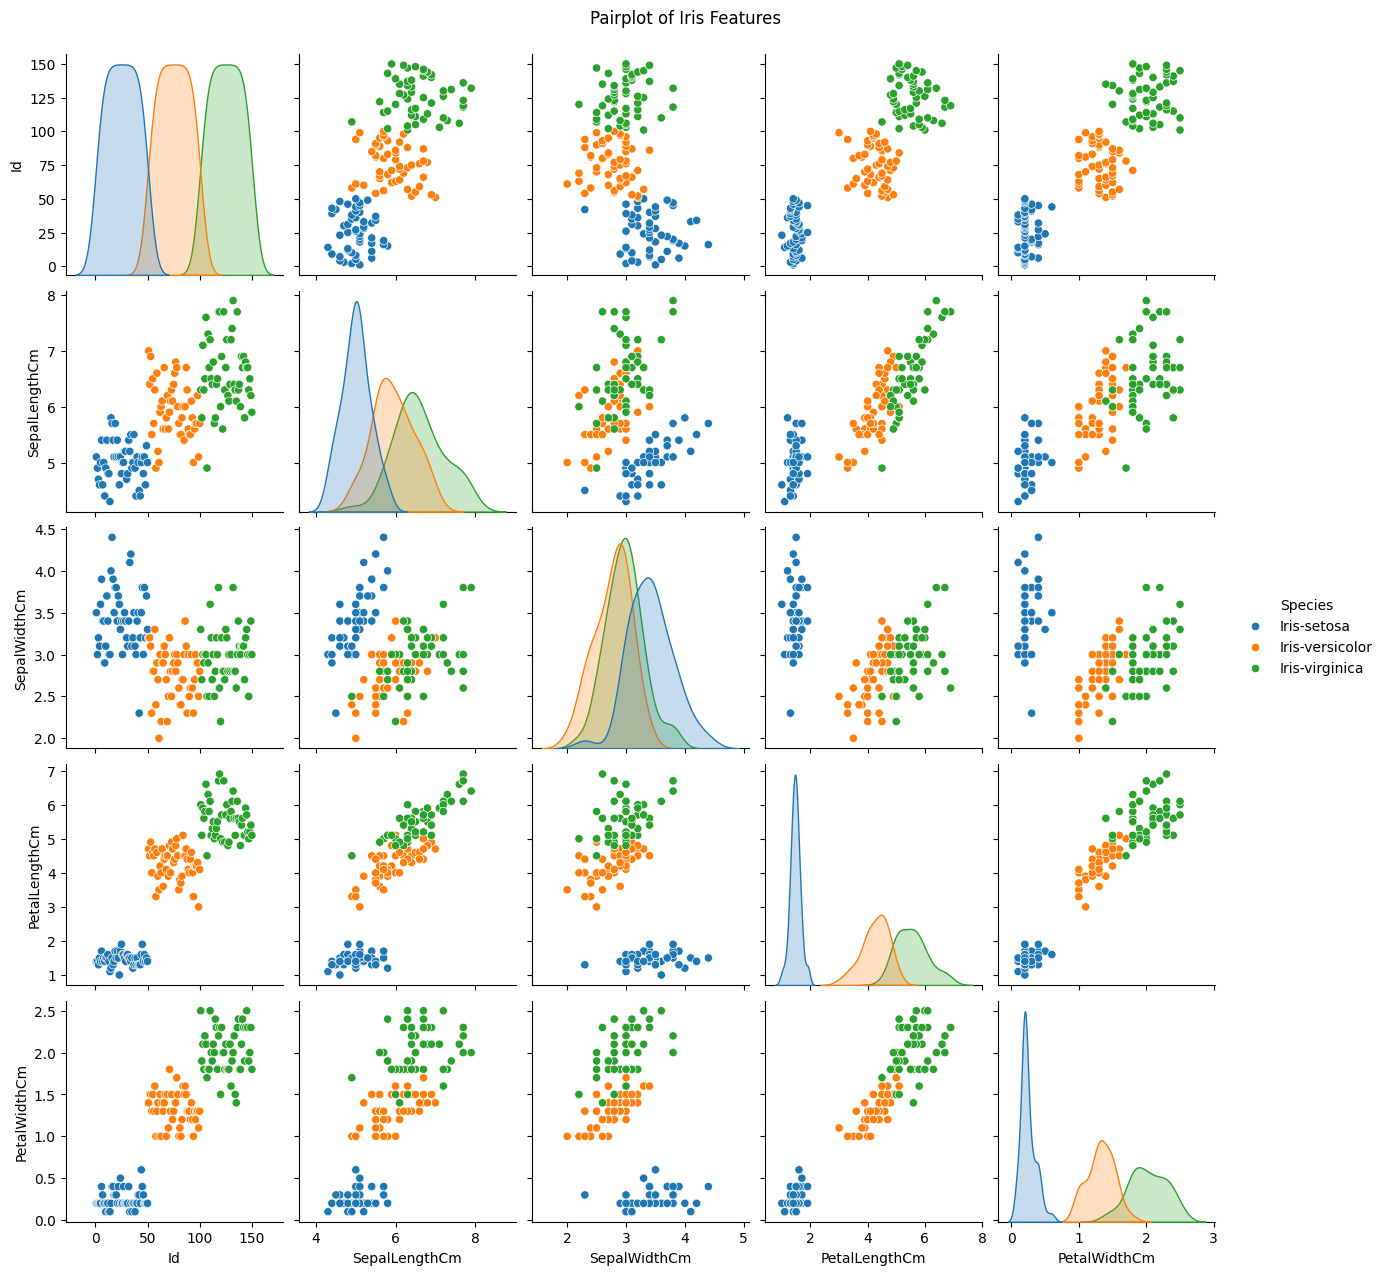

In [9]:
# Pairplot
sns.pairplot(df, hue="Species")
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

In [14]:
# Drop ID column if it exists
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Encode target variable
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Split into features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\n Training set size: ",X_train.shape)
print("Testing set size: ",X_test.shape)


 Training set size:  (120, 4)
Testing set size:  (30, 4)


In [15]:
# Step 6: Initialize Models
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')

In [16]:
# Step 7: Train Models
ada.fit(X_train, y_train)
gbm.fit(X_train, y_train)
xgb.fit(X_train, y_train)

C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\VAIBHAV ADMANE\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
# Step 8: Predictions
y_pred_ada = ada.predict(X_test)
y_pred_gbm = gbm.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [18]:
print("\n=== AdaBoost Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))


=== AdaBoost Performance ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
print("\n=== Gradient Boosting Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gbm))
print(classification_report(y_test, y_pred_gbm))


=== Gradient Boosting Performance ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
print("\n=== XGBoost Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


=== XGBoost Performance ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



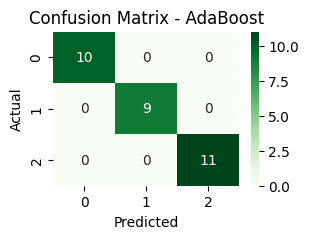

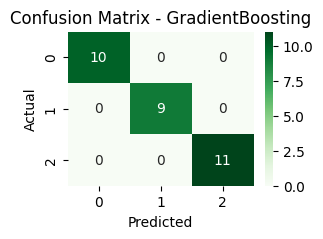

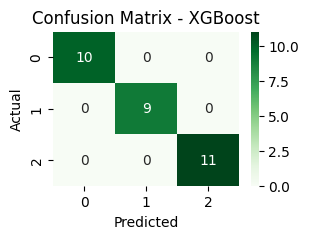

In [21]:
models = ['AdaBoost', 'GradientBoosting', 'XGBoost']
preds = [y_pred_ada, y_pred_gbm, y_pred_xgb]

for i, pred in enumerate(preds):
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(3,2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Confusion Matrix - {models[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

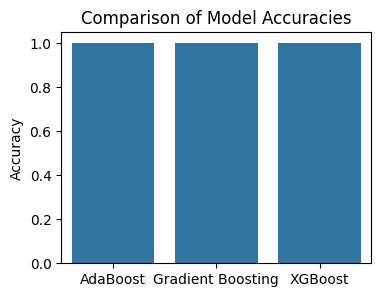

In [22]:
acc_scores = {
    'AdaBoost': accuracy_score(y_test, y_pred_ada),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gbm),
    'XGBoost': accuracy_score(y_test, y_pred_xgb)
}
plt.figure(figsize=(4,3))
sns.barplot(x=list(acc_scores.keys()), y=list(acc_scores.values()))
plt.title("Comparison of Model Accuracies")
plt.ylabel("Accuracy")
plt.show()

In [23]:
voting_clf = VotingClassifier(
    estimators=[('ada', ada), ('gbm', gbm), ('xgb', xgb)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)

print("\n=== Voting Classifier (Soft Voting) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print(classification_report(y_test, y_pred_vote))

# ... (Confusion Matrix plot code)...

C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== Voting Classifier (Soft Voting) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



C:\Users\VAIBHAV ADMANE\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:24:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


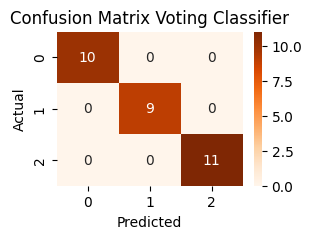

In [24]:
# Calculate the confusion matrix for the voting classifier
cm = confusion_matrix(y_test, y_pred_vote)

# Plot the heatmap
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()